# Наивный байесовский классификатор

В этом ноутбуке разберём **наивный байесовский классификатор** как простой и эффективный метод для классификации.

**Цели ноутбука:**
- Напомнить формулу Байеса и её интерпретацию.
- Понять, в чём состоит "наивность" предположений.
- Реализовать **Gaussian Naive Bayes с нуля** на `numpy`.
- Сравнить с `GaussianNB` из `sklearn` на синтетическом датасете.

---

**Содержание:** Формула Байеса → Наивное предположение → Gaussian NB с нуля → Сравнение с sklearn.


## Формула Байеса и идея классификатора

Пусть у нас есть классы $C_1, \dots, C_K$ и объект с признаками $x$.
Нас интересует **апостериорная вероятность** класса при наблюдённых признаках: $P(C_k \mid x)$.

По формуле Байеса:
$$
P(C_k \mid x) = \frac{P(x \mid C_k) P(C_k)}{P(x)}.
$$
В классификации знаменатель $P(x)$ одинаков для всех классов, поэтому достаточно сравнивать **числитель**:
$$
P(x \mid C_k) P(C_k).
$$

Байесовский классификатор выбирает класс с максимальной апостериорной вероятностью:
$$
\hat{y}(x) = \arg\max_k P(x \mid C_k) P(C_k).
$$


## Наивное предположение

Проблема: плотность $P(x \mid C_k)$ в общем случае сложна, особенно в многомерном пространстве.

**Наивное предположение**: признаки условно **независимы** при фиксированном классе:
$$
P(x \mid C_k) = \prod_{j=1}^d P(x_j \mid C_k).
$$
Тогда
$$
P(C_k \mid x) \propto P(C_k) \prod_{j=1}^d P(x_j \mid C_k).
$$

На практике независимость признаков почти никогда не выполняется, но **наивный байес** часто работает удивительно хорошо, особенно:
- в задачах с большим числом признаков и относительно небольшим числом наблюдений,
- в текстовой классификации (модель "мешка слов").


## Gaussian Naive Bayes

Рассмотрим вариант для **вещественных признаков**: предположим, что каждый признак $x_j$ при условии класса $C_k$ распределён нормально:
$$
x_j \mid C_k \sim \mathcal{N}(\mu_{k,j}, \sigma_{k,j}^2).
$$
Тогда
$$
P(x_j \mid C_k) = \frac{1}{\sqrt{2\pi \sigma_{k,j}^2}} \exp\left(-\frac{(x_j - \mu_{k,j})^2}{2\sigma_{k,j}^2}\right).
$$

Подставляя в произведение по признакам и умножая на априорную вероятность $P(C_k)$, получаем
классификатор, который можно удобно реализовать в **логарифмическом масштабе** (чтобы избежать численных переполнений):
$$
\log P(C_k \mid x) = \log P(C_k) + \sum_{j=1}^d \log P(x_j \mid C_k) - \log P(x).
$$
Здесь $P(x)$ — полная вероятность наблюдать объект с признаками $x$ (одинакова для всех классов). При сравнении классов по $\arg\max_k \log P(C_k \mid x)$ этот член ведёт себя как **константа по $k$**, поэтому его часто записывают как $+\text{const}$ и опускают из формулы.


## Синтетические данные

Сгенерируем простые двумерные данные для двух классов, чтобы:
- получить наглядное изображение в 2D,
- обучить на них наш Gaussian Naive Bayes с нуля,
- сравнить с `GaussianNB` из `sklearn`.


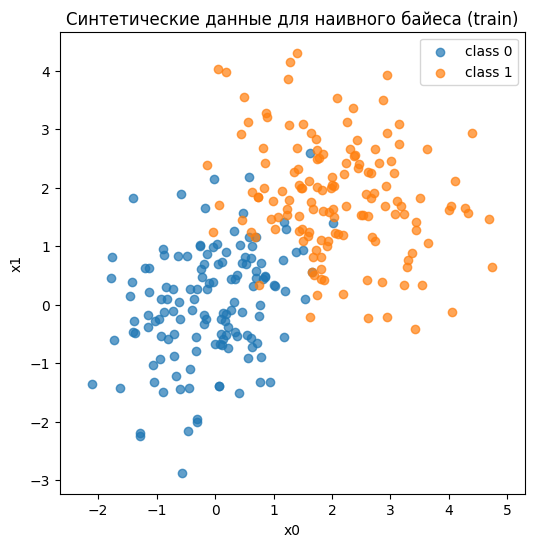

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(42)

n_samples = 400
n_features = 2

mean0 = [0, 0]
mean1 = [2, 2]
cov0 = [[1.0, 0.3], [0.3, 1.0]]
cov1 = [[1.0, -0.2], [-0.2, 1.0]]

X0 = np.random.multivariate_normal(mean0, cov0, size=n_samples // 2)
X1 = np.random.multivariate_normal(mean1, cov1, size=n_samples // 2)
X = np.vstack([X0, X1])
y = np.array([0] * (n_samples // 2) + [1] * (n_samples // 2))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color="tab:blue", alpha=0.7, label="class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color="tab:orange", alpha=0.7, label="class 1")
plt.title("Синтетические данные для наивного байеса (train)")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.axis("equal")
plt.show()


## Реализация Gaussian Naive Bayes с нуля

Реализуем простой вариант:
- на `fit` для каждого класса оцениваем:
  - априорную вероятность $P(C_k)$ как долю объектов,
  - средние $\mu_{k,j}$ и дисперсии $\sigma_{k,j}^2$ по каждому признаку,
- на `predict_proba` и `predict` считаем логарифмы апостериорных вероятностей (с точностью до константы по классам $k$, т.е. с точностью до общего нормирующего множителя)
  и выбираем класс с максимальным значением.


In [2]:
class GaussianNaiveBayesScratch:
    def __init__(self, var_smoothing: float = 1e-9):
        self.var_smoothing = var_smoothing
        self.classes_ = None
        self.priors_ = None        # P(C_k)
        self.means_ = None         # shape (n_classes, n_features)
        self.vars_ = None          # shape (n_classes, n_features)

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples, n_features = X.shape

        self.classes_, counts = np.unique(y, return_counts=True)
        n_classes = len(self.classes_)

        self.priors_ = counts / n_samples
        self.means_ = np.zeros((n_classes, n_features))
        self.vars_ = np.zeros((n_classes, n_features))

        for idx, cls in enumerate(self.classes_):
            X_k = X[y == cls]
            self.means_[idx, :] = X_k.mean(axis=0)
            self.vars_[idx, :] = X_k.var(axis=0) + self.var_smoothing

        return self

    def _log_gaussian_density(self, X: np.ndarray) -> np.ndarray:
        """Вычисляем log P(X | C_k) для всех классов и объектов.

        X: shape (n_samples, n_features)
        return: shape (n_samples, n_classes)
        """
        X = np.asarray(X)
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        log_probs = np.zeros((n_samples, n_classes))

        for idx in range(n_classes):
            mean = self.means_[idx]
            var = self.vars_[idx]
            # формула логарифма плотности нормального распределения по признакам (суммируем по j)
            log_prob = -0.5 * np.sum(
                np.log(2.0 * np.pi * var) + ((X - mean) ** 2) / var,
                axis=1,
            )
            log_probs[:, idx] = log_prob

        return log_probs

    def predict_log_proba(self, X: np.ndarray) -> np.ndarray:
        log_likelihood = self._log_gaussian_density(X)             # log P(X | C_k)
        log_prior = np.log(self.priors_)                           # log P(C_k)
        # log P(C_k | X) ∝ log P(X | C_k) + log P(C_k)
        return log_likelihood + log_prior

    def predict(self, X: np.ndarray) -> np.ndarray:
        log_post = self.predict_log_proba(X)
        idx = np.argmax(log_post, axis=1)
        return self.classes_[idx]


gnb_scratch = GaussianNaiveBayesScratch(var_smoothing=1e-6)
gnb_scratch.fit(X_train, y_train)

y_pred_train = gnb_scratch.predict(X_train)
y_pred_test = gnb_scratch.predict(X_test)

train_acc = (y_pred_train == y_train).mean()
test_acc = (y_pred_test == y_test).mean()

print(f"Точность (scratch) train: {train_acc:.3f}")
print(f"Точность (scratch) test : {test_acc:.3f}")


Точность (scratch) train: 0.936
Точность (scratch) test : 0.917


## Визуализация границы решений (scratch)

Построим границу решений для нашего самописного Gaussian Naive Bayes в 2D, чтобы увидеть, как он разделяет классы.


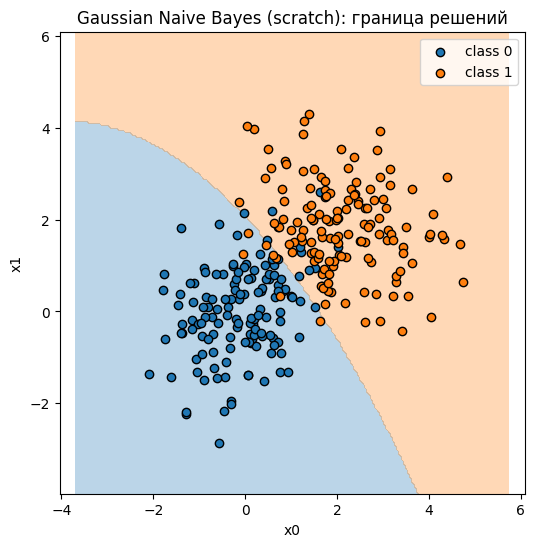

In [3]:
# Сетка по двумерному пространству
x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]
zz = gnb_scratch.predict(grid)
zz = zz.reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, zz, alpha=0.3, levels=[-0.5, 0.5, 1.5], colors=["tab:blue", "tab:orange"])
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color="tab:blue", edgecolor="k", label="class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color="tab:orange", edgecolor="k", label="class 1")
plt.title("Gaussian Naive Bayes (scratch): граница решений")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.axis("equal")
plt.show()


## GaussianNB из `sklearn`

Теперь воспользуемся готовой реализацией `GaussianNB` из `scikit-learn` и сравним результаты.


Точность (sklearn) train: 0.936
Точность (sklearn) test : 0.917


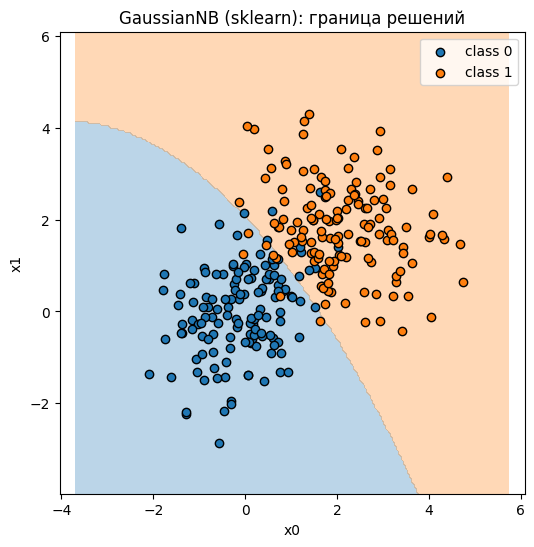

In [4]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

gnb = GaussianNB(var_smoothing=1e-6)
gnb.fit(X_train, y_train)

y_pred_train_sk = gnb.predict(X_train)
y_pred_test_sk = gnb.predict(X_test)

train_acc_sk = accuracy_score(y_train, y_pred_train_sk)
test_acc_sk = accuracy_score(y_test, y_pred_test_sk)

print(f"Точность (sklearn) train: {train_acc_sk:.3f}")
print(f"Точность (sklearn) test : {test_acc_sk:.3f}")

# Визуализируем границу решений sklearn-модели
zz_sk = gnb.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, zz_sk, alpha=0.3, levels=[-0.5, 0.5, 1.5], colors=["tab:blue", "tab:orange"])
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color="tab:blue", edgecolor="k", label="class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color="tab:orange", edgecolor="k", label="class 1")
plt.title("GaussianNB (sklearn): граница решений")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.axis("equal")
plt.show()


## Выводы

- Наивный байес основан на формуле Байеса и предположении условной независимости признаков; это упрощение редко строго выполняется, но благодаря малому числу параметров модель часто хорошо обобщает.
- Для вещественных признаков используют гауссовы плотности по классам (GaussianNB); реализация с нуля (оценка средних и дисперсий, предсказание по максимуму апостериорной вероятности) совпадает по идее с sklearn; в sklearn есть также мультиномиальный и бернуллиевский варианты.
- Метод прост и быстр, часто даёт хорошее качество при ограниченном объёме данных; при сильном нарушении предположений возможны смещённые оценки.